# 03 - Tree-Based Models for Gasoline Price Forecasting

This notebook trains and evaluates tree-based models (Random Forest, XGBoost) for weekly gasoline price prediction.

- No feature standardization needed for tree models
- TimeSeriesSplit for cross-validation to respect temporal ordering
- Horizons: 1-week and 4-week ahead

## 1. Setup

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, os.path.join(os.path.abspath(''), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import xgboost as xgb

import data_utils
from data_utils import TARGET_COL
from evaluate import evaluate_model, save_results, plot_predictions_vs_actual

print('Setup complete.')

Setup complete.


## 2. Load Data (Horizon = 1)

In [2]:
data = data_utils.prepare_data(horizon=1, feature_mode='full')
feature_cols = data['feature_cols']

train_df = data['train']
val_df = data['val']
test_df = data['test']

X_train = train_df[feature_cols].values
y_train = train_df['target'].values
X_val = val_df[feature_cols].values
y_val = val_df['target'].values
X_test = test_df[feature_cols].values
y_test = test_df['target'].values

dates_val = val_df['Date'].values
dates_test = test_df['Date'].values

print(f'Features: {len(feature_cols)}')
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Feature columns: {feature_cols}')

Features: 26
Train: (943, 26), Val: (202, 26), Test: (203, 26)
Feature columns: ['A1_lag1', 'A1_lag2', 'A1_lag3', 'A1_lag4', 'A1_lag8', 'A1_lag12', 'A1_rolling_mean_4', 'A1_rolling_std_4', 'A1_rolling_mean_8', 'A1_rolling_std_8', 'A1_rolling_mean_12', 'A1_rolling_std_12', 'A1_diff_1', 'A1_diff_4', 'A1_pct_change_1', 'A1_pct_change_4', 'month', 'quarter', 'year', 'week_of_year', 'month_sin', 'month_cos', 'R1_lag1', 'M1_lag1', 'P1_lag1', 'D1_lag1']


## 3. Random Forest

### 3.1 Default Random Forest

In [3]:
rf_default = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)

y_val_pred_rf_def = rf_default.predict(X_val)
y_test_pred_rf_def = rf_default.predict(X_test)

print('Random Forest (default) - Validation:')
print(evaluate_model(y_val, y_val_pred_rf_def))
print('\nRandom Forest (default) - Test:')
print(evaluate_model(y_test, y_test_pred_rf_def))

Random Forest (default) - Validation:
{'RMSE': np.float64(0.076567), 'MAE': np.float64(0.056316), 'MAPE': np.float64(2.0799)}

Random Forest (default) - Test:
{'RMSE': np.float64(0.117364), 'MAE': np.float64(0.098616), 'MAPE': np.float64(3.8385)}


### 3.2 Random Forest - Hyperparameter Tuning with GridSearchCV

In [4]:
rf_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
}

tscv = TimeSeriesSplit(n_splits=3)

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

print(f'\nBest RF params: {rf_grid.best_params_}')
print(f'Best CV score (neg MSE): {rf_grid.best_score_:.6f}')

Fitting 3 folds for each of 36 candidates, totalling 108 fits



Best RF params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 500}
Best CV score (neg MSE): -0.445121


### 3.3 Evaluate Tuned Random Forest

In [5]:
rf_best = rf_grid.best_estimator_

y_val_pred_rf = rf_best.predict(X_val)
y_test_pred_rf = rf_best.predict(X_test)

rf_val_metrics = evaluate_model(y_val, y_val_pred_rf)
rf_test_metrics = evaluate_model(y_test, y_test_pred_rf)

print('Tuned Random Forest - Validation:')
print(rf_val_metrics)
print('\nTuned Random Forest - Test:')
print(rf_test_metrics)

# Save results
save_results(
    model_name='Random Forest',
    horizon=1,
    metrics={'val': rf_val_metrics, 'test': rf_test_metrics},
    predictions={'val': y_val_pred_rf, 'test': y_test_pred_rf},
    dates={'val': dates_val, 'test': dates_test},
    feature_mode='full',
)

Tuned Random Forest - Validation:
{'RMSE': np.float64(0.079674), 'MAE': np.float64(0.056714), 'MAPE': np.float64(2.0866)}

Tuned Random Forest - Test:
{'RMSE': np.float64(0.10652), 'MAE': np.float64(0.090126), 'MAPE': np.float64(3.5138)}
Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/notebooks/../src/../results/random_forest_h1_full.json


## 4. XGBoost

### 4.1 Default XGBoost

In [6]:
xgb_default = xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)
xgb_default.fit(X_train, y_train)

y_val_pred_xgb_def = xgb_default.predict(X_val)
y_test_pred_xgb_def = xgb_default.predict(X_test)

print('XGBoost (default) - Validation:')
print(evaluate_model(y_val, y_val_pred_xgb_def))
print('\nXGBoost (default) - Test:')
print(evaluate_model(y_test, y_test_pred_xgb_def))

XGBoost (default) - Validation:
{'RMSE': np.float64(0.066543), 'MAE': np.float64(0.052446), 'MAPE': np.float64(1.9621)}

XGBoost (default) - Test:
{'RMSE': np.float64(0.095742), 'MAE': np.float64(0.073952), 'MAPE': np.float64(2.8324)}


### 4.2 XGBoost - Hyperparameter Tuning with GridSearchCV

In [7]:
xgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
}

tscv = TimeSeriesSplit(n_splits=3)

xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)
xgb_grid.fit(X_train, y_train)

print(f'\nBest XGBoost params: {xgb_grid.best_params_}')
print(f'Best CV score (neg MSE): {xgb_grid.best_score_:.6f}')

Fitting 3 folds for each of 54 candidates, totalling 162 fits



Best XGBoost params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
Best CV score (neg MSE): -0.427392


### 4.3 Evaluate Tuned XGBoost

In [8]:
xgb_best = xgb_grid.best_estimator_

y_val_pred_xgb = xgb_best.predict(X_val)
y_test_pred_xgb = xgb_best.predict(X_test)

xgb_val_metrics = evaluate_model(y_val, y_val_pred_xgb)
xgb_test_metrics = evaluate_model(y_test, y_test_pred_xgb)

print('Tuned XGBoost - Validation:')
print(xgb_val_metrics)
print('\nTuned XGBoost - Test:')
print(xgb_test_metrics)

# Save results
save_results(
    model_name='XGBoost',
    horizon=1,
    metrics={'val': xgb_val_metrics, 'test': xgb_test_metrics},
    predictions={'val': y_val_pred_xgb, 'test': y_test_pred_xgb},
    dates={'val': dates_val, 'test': dates_test},
    feature_mode='full',
)

Tuned XGBoost - Validation:
{'RMSE': np.float64(0.056979), 'MAE': np.float64(0.044948), 'MAPE': np.float64(1.6402)}

Tuned XGBoost - Test:
{'RMSE': np.float64(0.077197), 'MAE': np.float64(0.061022), 'MAPE': np.float64(2.3573)}
Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/notebooks/../src/../results/xgboost_h1_full.json


## 5. Feature Importance Comparison

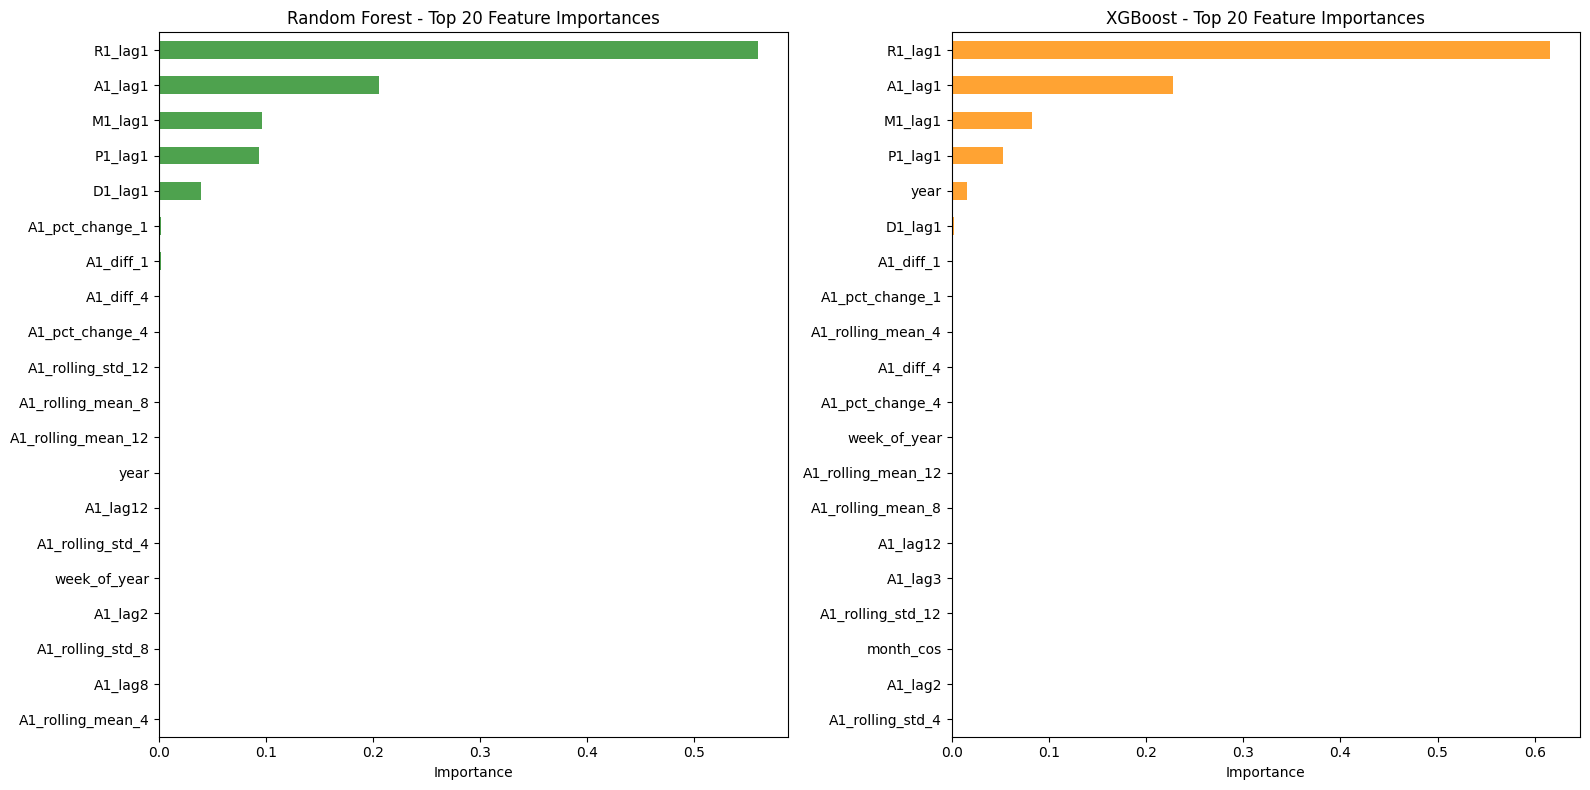


Shared features in top 20: 18
Shared: ['A1_diff_1', 'A1_diff_4', 'A1_lag1', 'A1_lag12', 'A1_lag2', 'A1_pct_change_1', 'A1_pct_change_4', 'A1_rolling_mean_12', 'A1_rolling_mean_4', 'A1_rolling_mean_8', 'A1_rolling_std_12', 'A1_rolling_std_4', 'D1_lag1', 'M1_lag1', 'P1_lag1', 'R1_lag1', 'week_of_year', 'year']

RF only: ['A1_lag8', 'A1_rolling_std_8']
XGB only: ['A1_lag3', 'month_cos']


In [9]:
# Get feature importances from both models
rf_importances = pd.Series(rf_best.feature_importances_, index=feature_cols)
xgb_importances = pd.Series(xgb_best.feature_importances_, index=feature_cols)

# Top 20 features for each
rf_top20 = rf_importances.nlargest(20)
xgb_top20 = xgb_importances.nlargest(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Random Forest
rf_top20.sort_values().plot.barh(ax=axes[0], color='forestgreen', alpha=0.8)
axes[0].set_title('Random Forest - Top 20 Feature Importances')
axes[0].set_xlabel('Importance')

# XGBoost
xgb_top20.sort_values().plot.barh(ax=axes[1], color='darkorange', alpha=0.8)
axes[1].set_title('XGBoost - Top 20 Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Compare overlap in top features
rf_top_set = set(rf_top20.index)
xgb_top_set = set(xgb_top20.index)
shared = rf_top_set & xgb_top_set
print(f'\nShared features in top 20: {len(shared)}')
print(f'Shared: {sorted(shared)}')
print(f'\nRF only: {sorted(rf_top_set - xgb_top_set)}')
print(f'XGB only: {sorted(xgb_top_set - rf_top_set)}')

## 6. 4-Week Horizon

Repeat the best-performing tree model with horizon=4 and compare to horizon=1.

In [10]:
# Load data for horizon=4
data_h4 = data_utils.prepare_data(horizon=4, feature_mode='full')
feature_cols_h4 = data_h4['feature_cols']

X_train_h4 = data_h4['train'][feature_cols_h4].values
y_train_h4 = data_h4['train']['target'].values
X_val_h4 = data_h4['val'][feature_cols_h4].values
y_val_h4 = data_h4['val']['target'].values
X_test_h4 = data_h4['test'][feature_cols_h4].values
y_test_h4 = data_h4['test']['target'].values

dates_val_h4 = data_h4['val']['Date'].values
dates_test_h4 = data_h4['test']['Date'].values

print(f'Horizon=4 - Train: {X_train_h4.shape}, Val: {X_val_h4.shape}, Test: {X_test_h4.shape}')

Horizon=4 - Train: (941, 26), Val: (202, 26), Test: (202, 26)


In [11]:
# Train Random Forest with best params on horizon=4
rf_h4 = RandomForestRegressor(**rf_grid.best_params_, random_state=42, n_jobs=-1)
rf_h4.fit(X_train_h4, y_train_h4)

y_val_pred_rf_h4 = rf_h4.predict(X_val_h4)
y_test_pred_rf_h4 = rf_h4.predict(X_test_h4)

rf_h4_val_metrics = evaluate_model(y_val_h4, y_val_pred_rf_h4)
rf_h4_test_metrics = evaluate_model(y_test_h4, y_test_pred_rf_h4)

print('Random Forest (h=4) - Validation:')
print(rf_h4_val_metrics)
print('\nRandom Forest (h=4) - Test:')
print(rf_h4_test_metrics)

save_results(
    model_name='Random Forest',
    horizon=4,
    metrics={'val': rf_h4_val_metrics, 'test': rf_h4_test_metrics},
    predictions={'val': y_val_pred_rf_h4, 'test': y_test_pred_rf_h4},
    dates={'val': dates_val_h4, 'test': dates_test_h4},
    feature_mode='full',
)

Random Forest (h=4) - Validation:
{'RMSE': np.float64(0.193995), 'MAE': np.float64(0.147276), 'MAPE': np.float64(5.7162)}

Random Forest (h=4) - Test:
{'RMSE': np.float64(0.226862), 'MAE': np.float64(0.181171), 'MAPE': np.float64(7.2517)}
Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/notebooks/../src/../results/random_forest_h4_full.json


In [12]:
# Train XGBoost with best params on horizon=4
xgb_h4 = xgb.XGBRegressor(**xgb_grid.best_params_, random_state=42, n_jobs=-1, verbosity=0)
xgb_h4.fit(X_train_h4, y_train_h4)

y_val_pred_xgb_h4 = xgb_h4.predict(X_val_h4)
y_test_pred_xgb_h4 = xgb_h4.predict(X_test_h4)

xgb_h4_val_metrics = evaluate_model(y_val_h4, y_val_pred_xgb_h4)
xgb_h4_test_metrics = evaluate_model(y_test_h4, y_test_pred_xgb_h4)

print('XGBoost (h=4) - Validation:')
print(xgb_h4_val_metrics)
print('\nXGBoost (h=4) - Test:')
print(xgb_h4_test_metrics)

save_results(
    model_name='XGBoost',
    horizon=4,
    metrics={'val': xgb_h4_val_metrics, 'test': xgb_h4_test_metrics},
    predictions={'val': y_val_pred_xgb_h4, 'test': y_test_pred_xgb_h4},
    dates={'val': dates_val_h4, 'test': dates_test_h4},
    feature_mode='full',
)

XGBoost (h=4) - Validation:
{'RMSE': np.float64(0.196153), 'MAE': np.float64(0.15302), 'MAPE': np.float64(5.9084)}

XGBoost (h=4) - Test:
{'RMSE': np.float64(0.237876), 'MAE': np.float64(0.190156), 'MAPE': np.float64(7.5411)}
Results saved to /Users/simouchen/Documents/MasterYear/CSCI567/Project/CSCI567_FinalProject/notebooks/../src/../results/xgboost_h4_full.json


In [13]:
# Compare horizon=1 vs horizon=4
print('=== Horizon Comparison (Test Set) ===')
print(f'{"Model":<20} {"Horizon":>7} {"RMSE":>10} {"MAE":>10} {"MAPE":>10}')
print('-' * 60)
for name, h, metrics in [
    ('Random Forest', 1, rf_test_metrics),
    ('Random Forest', 4, rf_h4_test_metrics),
    ('XGBoost', 1, xgb_test_metrics),
    ('XGBoost', 4, xgb_h4_test_metrics),
]:
    print(f'{name:<20} {h:>7} {metrics["RMSE"]:>10.6f} {metrics["MAE"]:>10.6f} {metrics["MAPE"]:>10.4f}')

=== Horizon Comparison (Test Set) ===
Model                Horizon       RMSE        MAE       MAPE
------------------------------------------------------------
Random Forest              1   0.106520   0.090126     3.5138
Random Forest              4   0.226862   0.181171     7.2517
XGBoost                    1   0.077197   0.061022     2.3573
XGBoost                    4   0.237876   0.190156     7.5411


## 7. Predictions vs Actual Plots

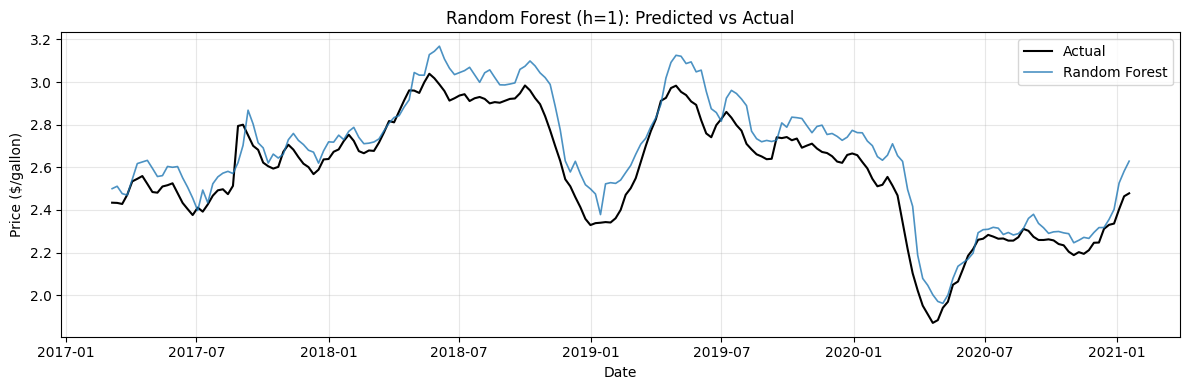

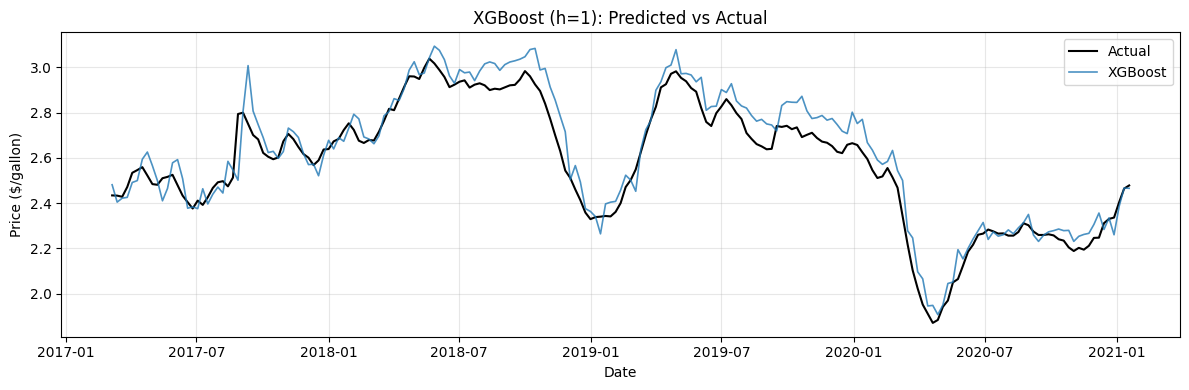

In [14]:
# Random Forest - Horizon 1
fig_rf = plot_predictions_vs_actual(
    dates_test, y_test, y_test_pred_rf,
    model_name='Random Forest',
    title='Random Forest (h=1): Predicted vs Actual'
)
plt.show()

# XGBoost - Horizon 1
fig_xgb = plot_predictions_vs_actual(
    dates_test, y_test, y_test_pred_xgb,
    model_name='XGBoost',
    title='XGBoost (h=1): Predicted vs Actual'
)
plt.show()

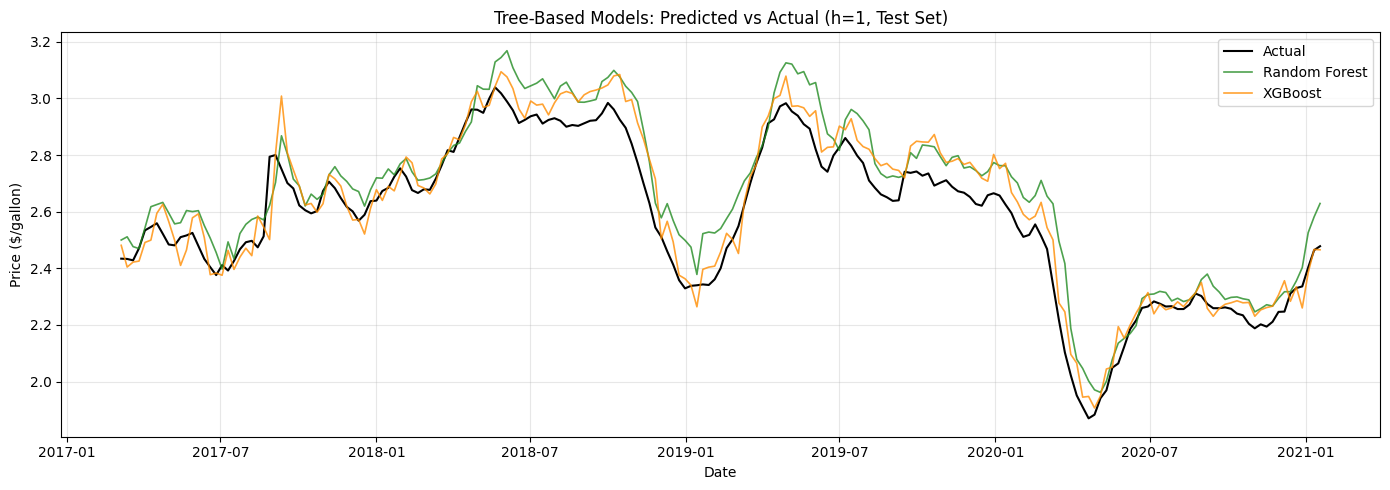

In [15]:
# Both models on same plot for comparison
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_test, y_test, label='Actual', color='black', linewidth=1.5)
ax.plot(dates_test, y_test_pred_rf, label='Random Forest', color='forestgreen',
        linewidth=1.2, alpha=0.8)
ax.plot(dates_test, y_test_pred_xgb, label='XGBoost', color='darkorange',
        linewidth=1.2, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/gallon)')
ax.set_title('Tree-Based Models: Predicted vs Actual (h=1, Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary Table

In [16]:
summary_rows = []
for name, h, val_m, test_m in [
    ('Random Forest (default)', 1,
     evaluate_model(y_val, y_val_pred_rf_def),
     evaluate_model(y_test, y_test_pred_rf_def)),
    ('Random Forest (tuned)', 1, rf_val_metrics, rf_test_metrics),
    ('XGBoost (default)', 1,
     evaluate_model(y_val, y_val_pred_xgb_def),
     evaluate_model(y_test, y_test_pred_xgb_def)),
    ('XGBoost (tuned)', 1, xgb_val_metrics, xgb_test_metrics),
    ('Random Forest (tuned)', 4, rf_h4_val_metrics, rf_h4_test_metrics),
    ('XGBoost (tuned)', 4, xgb_h4_val_metrics, xgb_h4_test_metrics),
]:
    summary_rows.append({
        'Model': name,
        'Horizon': h,
        'Val RMSE': val_m['RMSE'],
        'Val MAE': val_m['MAE'],
        'Val MAPE': val_m['MAPE'],
        'Test RMSE': test_m['RMSE'],
        'Test MAE': test_m['MAE'],
        'Test MAPE': test_m['MAPE'],
    })

summary_df = pd.DataFrame(summary_rows)
print('=== Tree-Based Models Summary ===')
summary_df

=== Tree-Based Models Summary ===


,Model,Horizon,Val RMSE,Val MAE,Val MAPE,Test RMSE,Test MAE,Test MAPE
0,Random Forest (default),1,0.076567,0.056316,2.0799,0.117364,0.098616,3.8385
1,Random Forest (tuned),1,0.079674,0.056714,2.0866,0.106520,0.090126,3.5138
2,XGBoost (default),1,0.066543,0.052446,1.9621,0.095742,0.073952,2.8324
3,XGBoost (tuned),1,0.056979,0.044948,1.6402,0.077197,0.061022,2.3573
4,Random Forest (tuned),4,0.193995,0.147276,5.7162,0.226862,0.181171,7.2517
5,XGBoost (tuned),4,0.196153,0.153020,5.9084,0.237876,0.190156,7.5411
